In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import mean_squared_error, r2_score,accuracy_score,recall_score,f1_score

In [6]:
dataset2 = pd.read_csv('/Users/maheshg/Dropbox/Sample Datasets Kaggle/ensemble.csv')

In [7]:
dataset2.head()

,X1,X2,y
0,-0.665227,-0.161289,0
1,1.747817,-0.054035,0
2,0.792945,0.687195,1
3,0.533777,-1.436711,0
4,0.841554,0.912889,1


In [8]:
dataset2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X1      1000 non-null   float64
 1   X2      1000 non-null   float64
 2   y       1000 non-null   int64  
dtypes: float64(2), int64(1)
memory usage: 23.6 KB


In [11]:
X = dataset2[['X1','X2']]

In [13]:
y = dataset2['y']

In [51]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

Define the base models 

In [52]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

In [53]:
log_clf = LogisticRegression()
dt_clf = DecisionTreeClassifier()
knn_clf = KNeighborsClassifier()

In [54]:
voting_clf = VotingClassifier(
    estimators=[
        ('lr', log_clf),
        ('dt', dt_clf),
        ('knn', knn_clf)
    ],
    voting='hard'
)

In [55]:
voting_clf.fit(X_train, y_train)
y_pred = voting_clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

In [56]:
print(f'Accuracy: {accuracy * 100:.2f}%')

Accuracy: 80.40%


In [57]:
print(f'Recall: {recall * 100:.2f}%')

Recall: 57.14%


In [58]:
print(f'F1 Score: {f1 * 100:.2f}%')

F1 Score: 62.02%


In [59]:
models = {
    'VotingClassifier Ensemble': VotingClassifier(estimators=[
        ('lr', LogisticRegression()),
        ('dt', DecisionTreeClassifier()),
        ('knn', KNeighborsClassifier())
    ], voting='hard'),

    'DecisionTreeClassifier(max_depth=3)': DecisionTreeClassifier(max_depth=3),
    'KNeighborsClassifier(n_neighbors=4)': KNeighborsClassifier(n_neighbors=4),
    'KNeighborsClassifier(n_neighbors=5)': KNeighborsClassifier(n_neighbors=5),
    'KNeighborsClassifier(n_neighbors=3)': KNeighborsClassifier(n_neighbors=3),
    'DecisionTreeClassifier(max_depth=4)': DecisionTreeClassifier(max_depth=4)
}

In [60]:
from sklearn.metrics import precision_score

In [61]:
# Evaluate precision scores
precision_scores = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    score = precision_score(y_test, y_pred, zero_division=0)
    precision_scores[name] = score

# Display results
for name, score in precision_scores.items():
    print(f"{name}: Precision Score = {score:.2f}")

# Identify best model
best_model = max(precision_scores, key=precision_scores.get)
print(f"\n🏆 Best Precision Score: {best_model} with {precision_scores[best_model]:.2f}")

VotingClassifier Ensemble: Precision Score = 0.69
DecisionTreeClassifier(max_depth=3): Precision Score = 0.79
KNeighborsClassifier(n_neighbors=4): Precision Score = 0.69
KNeighborsClassifier(n_neighbors=5): Precision Score = 0.66
KNeighborsClassifier(n_neighbors=3): Precision Score = 0.65
DecisionTreeClassifier(max_depth=4): Precision Score = 0.78

🏆 Best Precision Score: DecisionTreeClassifier(max_depth=3) with 0.79


In [62]:
recall_scores = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    score = recall_score(y_test, y_pred, zero_division=0)
    recall_scores[name] = score

# Display results
for name, score in recall_scores.items():
    print(f"{name}: Recall Score = {score:.2f}")

# Identify best model
best_model = max(recall_scores, key=recall_scores.get)
print(f"\n🏆 Best Recall Score: {best_model} with {recall_scores[best_model]:.2f}")

VotingClassifier Ensemble: Recall Score = 0.57
DecisionTreeClassifier(max_depth=3): Recall Score = 0.44
KNeighborsClassifier(n_neighbors=4): Recall Score = 0.54
KNeighborsClassifier(n_neighbors=5): Recall Score = 0.63
KNeighborsClassifier(n_neighbors=3): Recall Score = 0.66
DecisionTreeClassifier(max_depth=4): Recall Score = 0.44

🏆 Best Recall Score: KNeighborsClassifier(n_neighbors=3) with 0.66


In [63]:
dataset3 = pd.read_csv('/Users/maheshg/Dropbox/Sample Datasets Kaggle/ensemble2.csv')

In [64]:
dataset3.head()

,X1,X2,X3,X4,X5,y
0,1.555730,0.628147,-0.567278,-2.548786,-1.575909,2
1,-1.760054,-0.417340,0.353626,2.383121,0.172636,0
2,-0.329064,-0.461760,-1.183120,1.436410,-1.228790,0
3,-1.801581,0.075704,1.623614,1.218431,1.051731,0
4,0.543973,-0.595228,-1.202407,0.872089,0.185406,0


In [65]:
dataset3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X1      1000 non-null   float64
 1   X2      1000 non-null   float64
 2   X3      1000 non-null   float64
 3   X4      1000 non-null   float64
 4   X5      1000 non-null   float64
 5   y       1000 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 47.0 KB


In [66]:
dataset3.describe()

,X1,X2,X3,X4,X5,y
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,-0.267090,-0.174022,-0.128434,0.610613,0.031579,0.409000
std,1.282626,0.509495,1.328040,1.236867,1.209951,0.672437
min,-4.693368,-1.719279,-4.022879,-3.224026,-3.664033,0.000000
25%,-0.963761,-0.492231,-1.124822,-0.136607,-0.983002,0.000000
50%,-0.209032,-0.178900,-0.479385,0.680229,0.246709,0.000000
75%,0.464777,0.119807,0.903428,1.498429,1.019397,1.000000
max,4.607026,1.697637,4.100911,4.292105,2.860860,2.000000


Define base regressors 

In [67]:
from sklearn.neighbors import KNeighborsRegressor

In [68]:
lr = LinearRegression()
dt = DecisionTreeRegressor(random_state=42)
knn = KNeighborsRegressor()

In [69]:
from sklearn.ensemble import VotingRegressor

In [70]:
voting_reg = VotingRegressor(
    estimators=[
        ('lr', lr),
        ('dt', dt),
        ('knn', knn)
    ]   
)

In [71]:
voting_reg.fit(X_train, y_train)
y_pred = voting_reg.predict(X_test)

In [72]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f'RMSE: {rmse:.2f}')

RMSE: 0.40


In [73]:
# Define models
models = {
    'KNeighborsRegressor(n_neighbors=5)': KNeighborsRegressor(n_neighbors=5),
    'DecisionTreeRegressor(max_depth=5)': DecisionTreeRegressor(max_depth=5, random_state=42),
    'LinearRegression': LinearRegression(),
    'VotingRegressor Ensemble': VotingRegressor(estimators=[
        ('lr', LinearRegression()),
        ('dt', DecisionTreeRegressor(max_depth=5, random_state=42)),
        ('knn', KNeighborsRegressor(n_neighbors=5))
    ])
}

# Evaluate RMSE scores
rmse_scores = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    rmse_scores[name] = rmse

# Display results
for name, score in rmse_scores.items():
    print(f"{name}: RMSE = {score:.4f}")

# Identify worst performer
worst_model = max(rmse_scores, key=rmse_scores.get)
print(f"\n📉 Highest RMSE: {worst_model} with {rmse_scores[worst_model]:.4f}")

KNeighborsRegressor(n_neighbors=5): RMSE = 0.3984
DecisionTreeRegressor(max_depth=5): RMSE = 0.3927
LinearRegression: RMSE = 0.3851
VotingRegressor Ensemble: RMSE = 0.3740

📉 Highest RMSE: KNeighborsRegressor(n_neighbors=5) with 0.3984


In [74]:
dataset3 = pd.read_csv('/Users/maheshg/Dropbox/Sample Datasets Kaggle/ensemble3.csv')

In [75]:
dataset3.head()

,X1,X2,X3,X4,X5,y
0,1.555730,0.628147,-0.567278,-2.548786,-1.575909,2
1,-1.760054,-0.417340,0.353626,2.383121,0.172636,0
2,-0.329064,-0.461760,-1.183120,1.436410,-1.228790,0
3,-1.801581,0.075704,1.623614,1.218431,1.051731,0
4,0.543973,-0.595228,-1.202407,0.872089,0.185406,0


In [76]:
dataset3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X1      1000 non-null   float64
 1   X2      1000 non-null   float64
 2   X3      1000 non-null   float64
 3   X4      1000 non-null   float64
 4   X5      1000 non-null   float64
 5   y       1000 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 47.0 KB


In [77]:
X = dataset3[['X1','X2','X3','X4',
              'X5']]

In [78]:
y = dataset3['y']

In [79]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [80]:
from sklearn.ensemble import RandomForestClassifier

In [81]:
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)

In [82]:
rf_clf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [83]:
y_pred = rf_clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')

Accuracy: 89.20%


In [ ]:
from sklearn.ensemble import 

In [86]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

In [87]:
y_pred = rf_clf.predict(X_test)
f1 = f1_score(y_test, y_pred, average='weighted')
print(f'F1 Score: {f1 * 100:.2f}%')

F1 Score: 90.97%


In [88]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:",cm)

Confusion Matrix: [[206   2   5]
 [  7  42   4]
 [  1   8  25]]


In [89]:
tp_label_0_0 = cm[0, 0]
print("True Positives for label 0:", tp_label_0_0)

True Positives for label 0: 206


Boosting in Python

In [1]:
from sklearn.model_selection import train_test_split

In [2]:
from sklearn.datasets import make_moons
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score

In [3]:
### Generate Synthetic Data
X, y = make_moons(n_samples=1000, noise=0.25, random_state=42)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

In [5]:
### Single Weak learner 
stump = DecisionTreeClassifier(max_depth=1, random_state=42)

In [6]:
### Full tree, for comparison
tree = DecisionTreeClassifier(random_state=42) ### no limit on max depth 

In [8]:
from sklearn.ensemble import AdaBoostClassifier

In [11]:
### Adaboost ensemble of 50 stumps 
ada = AdaBoostClassifier(estimator = DecisionTreeClassifier(max_depth=1),
                         n_estimators=50,
                            learning_rate=1.0, 
                            random_state=0)

In [12]:
### Fit model to training data 
stump.fit(X_train, y_train)
tree.fit(X_train, y_train)
ada.fit(X_train, y_train)

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1),
                   random_state=0)

In [19]:
### Genearate predictions on test data
stump_pred = stump.predict(X_test)
tree_pred = tree.predict(X_test)
ada_pred = ada.predict(X_test)

In [17]:
print(f'Stump Accuracy: {accuracy_score(y_test, stump_pred) * 100:.2f}%')
print(f'Tree Accuracy: {accuracy_score(y_test, tree_pred) * 100:.2f}%')
print(f'AdaBoost Accuracy: {accuracy_score(y_test, ada_pred) * 100:.2f}%')

Stump Accuracy: 82.33%
Tree Accuracy: 93.00%
AdaBoost Accuracy: 95.00%


In [21]:
def compute_metrics (name,y_test,y_preds):
    accuracy = accuracy_score(y_test, y_preds) * 100
    precision = precision_score(y_test, y_preds) * 100
    recall = recall_score(y_test, y_preds) * 100
    f1 = f1_score(y_test, y_preds) * 100
    print(f'{name} - Accuracy: {accuracy:.2f}%, Precision: {precision:.2f}%, Recall: {recall:.2f}%, F1 Score: {f1:.2f}%')
    return

In [22]:
compute_metrics('Stump', y_test, stump_pred)

Stump - Accuracy: 82.33%, Precision: 83.70%, Recall: 78.47%, F1 Score: 81.00%


In [23]:
compute_metrics('Full Decision Tree', y_test, tree_pred)

Full Decision Tree - Accuracy: 93.00%, Precision: 94.89%, Recall: 90.28%, F1 Score: 92.53%


In [24]:
compute_metrics('Adaboost', y_test, ada_pred)

Adaboost - Accuracy: 95.00%, Precision: 93.88%, Recall: 95.83%, F1 Score: 94.85%


In [28]:
cf_dataset1 = pd.read_csv('/Users/maheshg/Dropbox/Sample Datasets Kaggle/clf-dataset01.csv')

In [30]:
cf_dataset1.head()

,X1,X2,y
0,0.360289,0.907079,0
1,0.487743,-0.293079,1
2,0.802645,0.452520,0
3,1.021270,-0.503749,1
4,1.134119,0.011527,0


In [32]:
X = cf_dataset1[['X1','X2']]
y = cf_dataset1['y']

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42,
                                                    stratify=y)

In [35]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier

In [36]:
model = GradientBoostingClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')

Accuracy: 96.00%


In [37]:
f1 = f1_score(y_test, y_pred, average='weighted')
print(f'F1 Score: {f1 * 100:.2f}%')

F1 Score: 96.00%


In [38]:
from sklearn.metrics import precision_score, recall_score, f1_score

In [39]:
from sklearn.tree import DecisionTreeClassifier

In [40]:
gb = GradientBoostingClassifier(n_estimators=100,
                                learning_rate=0.1,
                                max_depth=3,
                                random_state=42)

In [41]:
gb.fit(X_train, y_train)

GradientBoostingClassifier(random_state=42)

In [42]:
### Extract the first stump
first_stump = gb.estimators_[0, 0]

In [43]:
raw_pred = first_stump.predict(X_test.values)

In [45]:
y_pred = (raw_pred > 0).astype(int)

In [49]:
weighted_precision = precision_score(y_test, y_pred, average='weighted')


In [50]:
print(f"Weighted Precision of the first stump: {weighted_precision:.2f}")

Weighted Precision of the first stump: 0.90


In [51]:
weighted_recall = recall_score(y_test, y_pred, average='weighted')
print(f"Weighted Recall of the first stump: {weighted_recall:.2f}")

Weighted Recall of the first stump: 0.90


In [52]:
clf_dataset2 = pd.read_csv('/Users/maheshg/Dropbox/Sample Datasets Kaggle/clf-dataset08.csv')

In [53]:
clf_dataset2.head()

,X1,X2,X3,X4,X5,X6,y
0,-0.318514,-0.182128,0.981894,-1.607560,1.680242,1.540194,1
1,1.028638,0.233708,1.923055,0.593557,1.949668,0.695116,1
2,-0.573774,-1.082063,-0.719297,-0.650003,-0.766568,0.309679,0
3,0.258538,-0.729560,-0.968332,-0.447322,-1.794882,-1.149108,0
4,1.238943,0.296422,1.942978,0.659246,1.805563,0.425472,1


In [54]:
X = clf_dataset2.iloc[:,:-1]
y = clf_dataset2.iloc[:,-1]

In [55]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42,
                                                    stratify=y)

In [57]:
from sklearn.neighbors import KNeighborsClassifier

In [62]:
from sklearn.svm import SVC

In [63]:
from sklearn.linear_model import LogisticRegression

In [64]:
estimators = [
    ('dt', DecisionTreeClassifier(max_depth=3, random_state=42)),
    ('knn', KNeighborsClassifier(n_neighbors=5)),
    ('svc', SVC(probability=True, random_state=42)),
    ('lr', LogisticRegression())
]

In [65]:
meta = LogisticRegression(random_state=42)

In [67]:
from sklearn.ensemble import StackingClassifier

In [68]:
stack = StackingClassifier(estimators=estimators,
                            final_estimator=meta,
                            cv=5)

In [71]:
stack.fit(X_train, y_train)

StackingClassifier(cv=5,
                   estimators=[('dt',
                                DecisionTreeClassifier(max_depth=3,
                                                       random_state=42)),
                               ('knn', KNeighborsClassifier()),
                               ('svc', SVC(probability=True, random_state=42)),
                               ('lr', LogisticRegression())],
                   final_estimator=LogisticRegression(random_state=42))

In [73]:
y_pred = stack.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')

Accuracy: 96.67%


In [74]:
meta_learner = LogisticRegression(random_state=42)

In [78]:
stacking_clf = StackingClassifier(
    estimators=estimators,
    final_estimator=meta_learner,
    cv=5,                    # 5-fold cross-validation for meta-features
    n_jobs=-1,               # Use all CPU cores
    passthrough=False        # Don't pass original features to meta-learner
)

In [79]:
stacking_clf.fit(X_train, y_train)

StackingClassifier(cv=5,
                   estimators=[('dt',
                                DecisionTreeClassifier(max_depth=3,
                                                       random_state=42)),
                               ('knn', KNeighborsClassifier()),
                               ('svc', SVC(probability=True, random_state=42)),
                               ('lr', LogisticRegression())],
                   final_estimator=LogisticRegression(random_state=42),
                   n_jobs=-1)

In [80]:
y_pred = stacking_clf.predict(X_test)

In [82]:
weighted_f1 = f1_score(y_test, y_pred, average='weighted')
print(f'Weighted F1 Score of first stump: {weighted_f1 * 100:.2f}%')

Weighted F1 Score of first stump: 96.64%


In [1]:
import random

In [11]:
random.seed(500)

In [12]:
###Simulate 1000 coin flips 
coin_tosses = [random.choice(['Heads', 'Tails']) for _ in range(1000)]
### Printing first 10 coin tosses
print(coin_tosses[:10])

['Tails', 'Tails', 'Tails', 'Tails', 'Heads', 'Heads', 'Tails', 'Heads', 'Heads', 'Heads']


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

In [14]:
### Convert to dataframes 
df_coin = pd.DataFrame(coin_tosses, columns=['Outcome'])

Number of Heads: 461, Number of Tails: 539


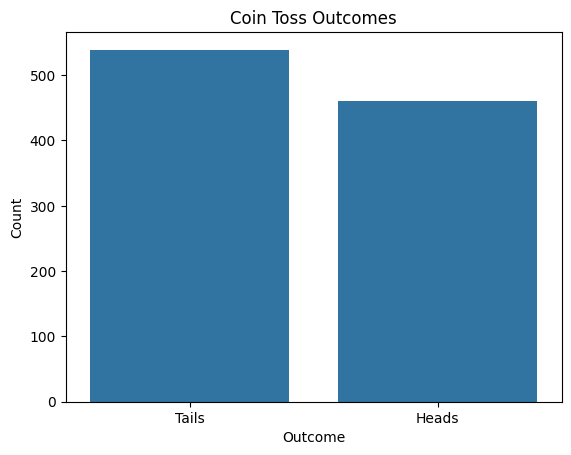

In [15]:
num_heads = df_coin['Outcome'].value_counts()['Heads']
num_tails = df_coin['Outcome'].value_counts()['Tails']
print(f'Number of Heads: {num_heads}, Number of Tails: {num_tails}')

###Plot coint tosses
sns.countplot(x='Outcome', data=df_coin)
plt.title('Coin Toss Outcomes')
plt.xlabel('Outcome')
plt.ylabel('Count')
plt.show()

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = [
    {"id": 1, "message": "free offer win", "label": "spam"},
    {"id": 2, "message": "win free", "label": "spam"},
    {"id": 3, "message": "offer free", "label": "spam"},
    {"id": 4, "message": "free win", "label": "spam"},
    {"id": 5, "message": "hello lunch", "label": "ham"},
    {"id": 6, "message": "lunch hello", "label": "ham"},
    {"id": 7, "message": "hello", "label": "ham"},
    {"id": 8, "message": "hello lunch", "label": "ham"},
]

In [4]:
totalmessage = len(data)
print(f'Total Messages: {totalmessage}')

Total Messages: 8


In [5]:
spam_messages = sum(1 for item in data if item['label'] == 'spam')
ham_messages = totalmessage - spam_messages

In [6]:
P_spam = spam_messages / totalmessage
P_ham = ham_messages / totalmessage
print(f'P(spam): {P_spam:.2f}, P(ham): {P_ham:.2f}')
print(f'P(spam): {P_spam:.2f}, P(ham): {P_ham:.2f}')

P(spam): 0.50, P(ham): 0.50
P(spam): 0.50, P(ham): 0.50


In [ ]:

# Word counts per class (from training set)
spam_counts = {"free": 2, "win": 1, "hello": 0}
ham_counts = {"free": 0, "win": 0, "hello": 2}
vocab = ["free", "win", "hello"]
V = len(vocab)

Time Series Analysis : 
    Exploratory Data Analysis 

Time Plot 

In [2]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import month_plot

In [4]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [8]:
import statsmodels.api as sm

In [9]:
co2_weekly = sm.datasets.co2.load_pandas().data

In [10]:
co2_monthly = co2_weekly['co2'].resample('M').mean()

/var/folders/bt/k7t4mr2j6kq79jv3vbj756z80000gn/T/ipykernel_8758/30668276.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  co2_monthly = co2_weekly['co2'].resample('M').mean()


In [11]:
co2_series = co2_monthly.interpolate()

In [12]:
plt.figure(figsize=(12, 6))

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

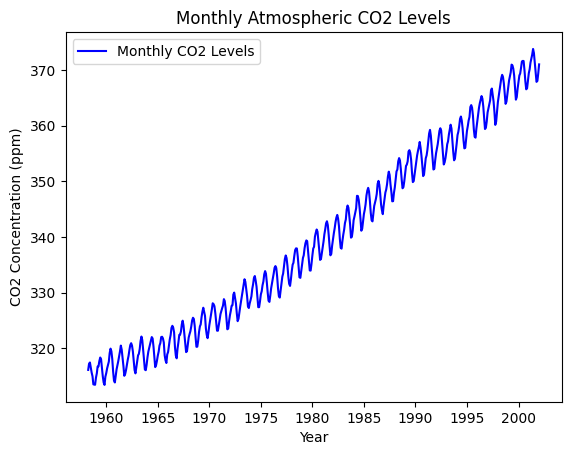

In [13]:
plt.plot(co2_series, label='Monthly CO2 Levels', color='blue')
plt.title('Monthly Atmospheric CO2 Levels')
plt.xlabel('Year')
plt.ylabel('CO2 Concentration (ppm)')
plt.legend()
plt.show()

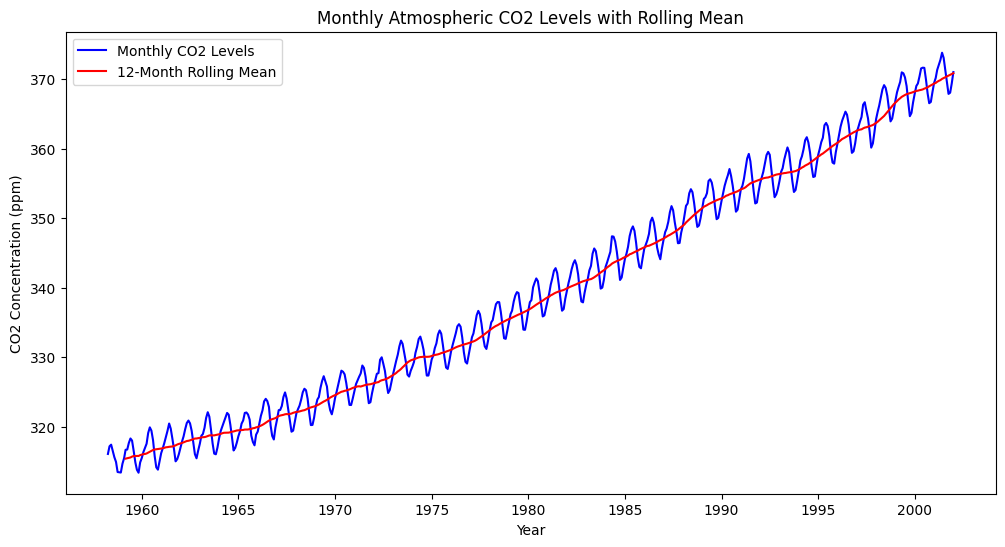

In [14]:
rolling_mean = co2_series.rolling(window=12).mean()
plt.figure(figsize=(12, 6))
plt.plot(co2_series, label='Monthly CO2 Levels', color='blue')
plt.plot(rolling_mean, label='12-Month Rolling Mean', color='red')
plt.title('Monthly Atmospheric CO2 Levels with Rolling Mean')
plt.xlabel('Year')
plt.ylabel('CO2 Concentration (ppm)')
plt.legend()
plt.show()

        Seasonal Plots :
            Seasonal Subseries plots 
            Seasonal Boxplots 

<Figure size 1200x600 with 0 Axes>

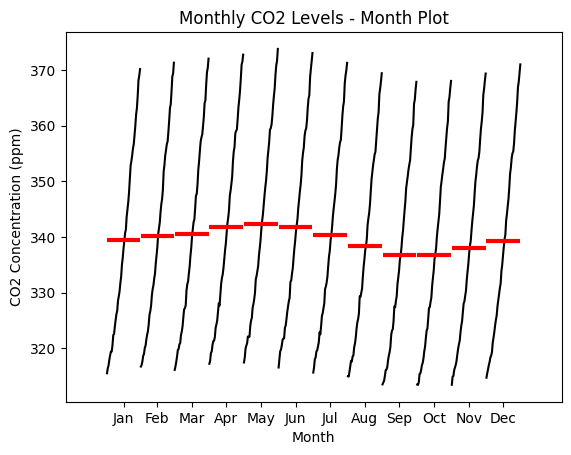

In [15]:
plt.figure(figsize=(12, 6))
month_plot(co2_series)
plt.title('Monthly CO2 Levels - Month Plot')
plt.xlabel('Month')
plt.ylabel('CO2 Concentration (ppm)')
plt.show()

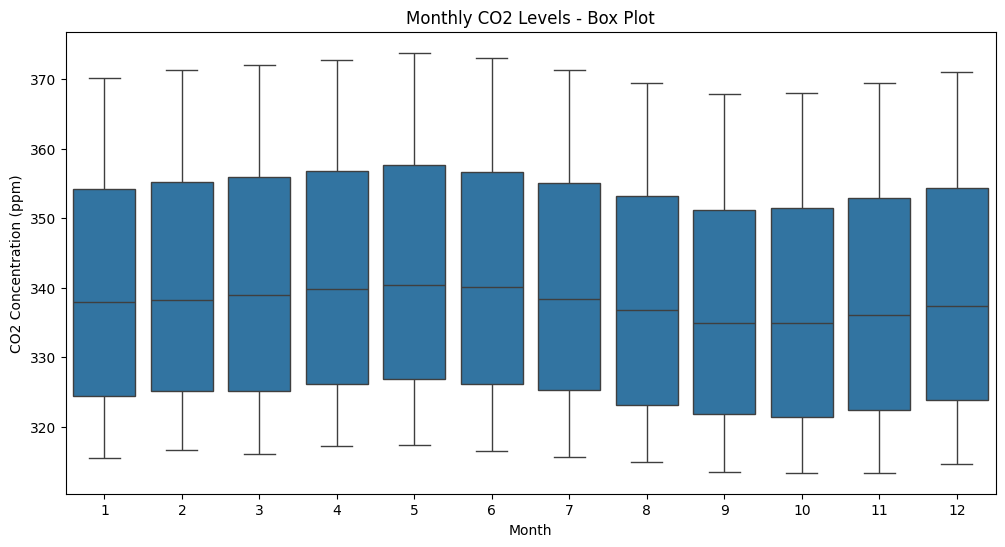

In [16]:
plt.figure(figsize=(12, 6))
sns.boxplot(x=co2_series.index.month, y=co2_series.values)
plt.title('Monthly CO2 Levels - Box Plot')
plt.xlabel('Month')
plt.ylabel('CO2 Concentration (ppm)')
plt.show()

In [21]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

Text(0.5, 0, 'Lags')

<Figure size 1200x600 with 0 Axes>

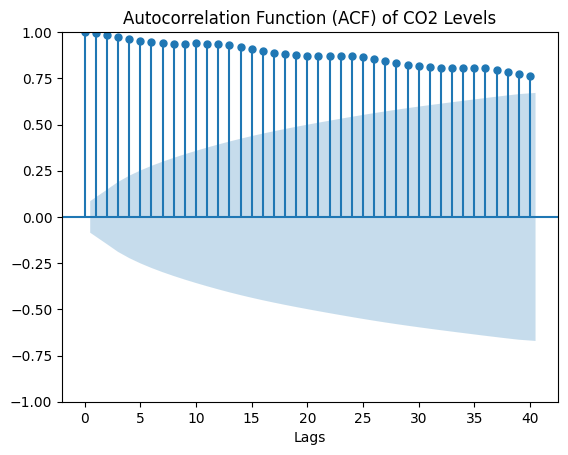

In [22]:
plt.figure(figsize=(12, 6))
plot_acf(co2_series, lags=40)
plt.title('Autocorrelation Function (ACF) of CO2 Levels')
plt.xlabel('Lags')

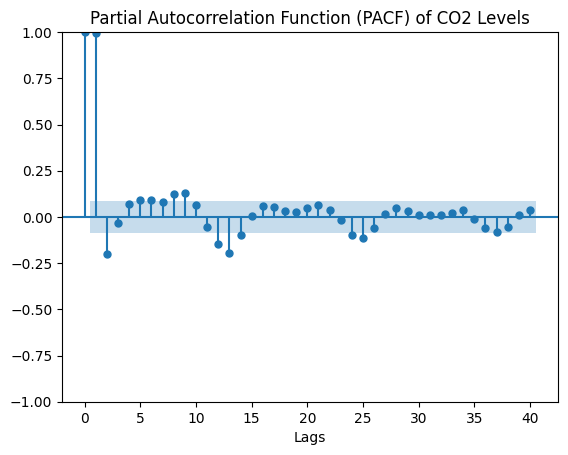

In [24]:
plot_pacf(co2_series, lags=40)
plt.title('Partial Autocorrelation Function (PACF) of CO2 Levels')
plt.xlabel('Lags')  
plt.show()

In [30]:
from statsmodels.graphics.tsaplots import plot_acf

In [28]:
from statsmodels.tsa.stattools import adfuller
adf_stat,adf_pvalue,adf_lags,adf_obs,adf_crit_values,adf_icbest = adfuller(co2_series)
print(f'ADF Statistic: {adf_stat}')
print(f'p-value: {adf_pvalue}')

ADF Statistic: 2.232835439898923
p-value: 0.9989084530577083


In [31]:
from statsmodels.graphics.tsaplots import plot_acf

In [33]:
ts = co2_series.copy()

In [34]:
ts.head()

1958-03-31    316.100000
1958-04-30    317.200000
1958-05-31    317.433333
1958-06-30    316.529167
1958-07-31    315.625000
Freq: ME, Name: co2, dtype: float64

In [35]:
outlier = '1975-05-31'

In [36]:
ts[outlier] = ts[outlier] + 100 ### Adding a large spike

In [37]:
ts.head()

1958-03-31    316.100000
1958-04-30    317.200000
1958-05-31    317.433333
1958-06-30    316.529167
1958-07-31    315.625000
Freq: ME, Name: co2, dtype: float64

In [38]:
mean_ts = ts.mean()
std_ts = ts.std()
uppoer_bound = mean_ts + 3 * std_ts
lower_bound = mean_ts - 3 * std_ts
outliers = ts[(ts > uppoer_bound) | (ts < lower_bound)]
print("Outliers detected:")
print(outliers)

Outliers detected:
1975-05-31    433.86
Freq: ME, Name: co2, dtype: float64


In [41]:
ts_with_nan = ts.copy()

In [42]:
ts_with_nan.head()

1958-03-31    316.100000
1958-04-30    317.200000
1958-05-31    317.433333
1958-06-30    316.529167
1958-07-31    315.625000
Freq: ME, Name: co2, dtype: float64

In [43]:
missing_date = '1989-07-31'
ts_with_nan[missing_date] = np.nan ### Introducing a missing value Nan


In [44]:
missing_indices = ts_with_nan[ts_with_nan.isna()].index
print("Missing values at indices:")
print(missing_indices)

Missing values at indices:
DatetimeIndex(['1989-07-31'], dtype='datetime64[ns]', freq='ME')


In [45]:
ts_filled = ts_with_nan.interpolate()

In [46]:
ts_filled

1958-03-31    316.100000
1958-04-30    317.200000
1958-05-31    317.433333
1958-06-30    316.529167
1958-07-31    315.625000
                 ...    
2001-08-31    369.425000
2001-09-30    367.880000
2001-10-31    368.050000
2001-11-30    369.375000
2001-12-31    371.020000
Freq: ME, Name: co2, Length: 526, dtype: float64

In [4]:
### Example ARIMA with D = 0 (Stationary ARIMA)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
### Loading the dataset 
df = pd.read_csv('/Users/maheshg/Dropbox/Sample Datasets Kaggle/APMM12-timeseries01.csv')

In [4]:
df.columns

Index(['date', 'value'], dtype='object')

In [5]:
ts = df['value']

In [6]:
### Compute ACF and PACF 

In [8]:
from statsmodels.tsa.stattools import acf, pacf

In [10]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [12]:
acf_values, confint = acf(ts,nlags = 20, alpha = 0.05, fft = False,
                          qstat=False) [:2]

In [13]:
print("Lag ACF Value Outside 95% Confidence Interval:")

Lag ACF Value Outside 95% Confidence Interval:


In [14]:
for lag,acf_val in enumerate(acf_values [1:],1):
    outside = abs(acf_val) > confint[lag][1] - acf_val
    print(f'Lag {lag}: ACF={acf_val:.4f}, Outside CI: {outside}')

Lag 1: ACF=0.4027, Outside CI: True
Lag 2: ACF=-0.0687, Outside CI: False
Lag 3: ACF=-0.0844, Outside CI: False
Lag 4: ACF=0.0203, Outside CI: False
Lag 5: ACF=0.1793, Outside CI: False
Lag 6: ACF=0.0585, Outside CI: False
Lag 7: ACF=-0.0709, Outside CI: False
Lag 8: ACF=-0.1288, Outside CI: False
Lag 9: ACF=-0.1148, Outside CI: False
Lag 10: ACF=-0.0397, Outside CI: False
Lag 11: ACF=0.0822, Outside CI: False
Lag 12: ACF=-0.0278, Outside CI: False
Lag 13: ACF=-0.0638, Outside CI: False
Lag 14: ACF=0.0691, Outside CI: False
Lag 15: ACF=-0.0095, Outside CI: False
Lag 16: ACF=-0.0153, Outside CI: False
Lag 17: ACF=-0.0316, Outside CI: False
Lag 18: ACF=0.0158, Outside CI: False
Lag 19: ACF=0.0549, Outside CI: False
Lag 20: ACF=-0.0474, Outside CI: False


=== AUTOCORRELATION FUNCTION (ACF) ===
Lag        ACF Significant?
  1     0.4027        YES
  2    -0.0687        no
  3    -0.0844        no
  4     0.0203        no
  5     0.1793        no
  6     0.0585        no
  7    -0.0709        no
  8    -0.1288        no
  9    -0.1148        no
 10    -0.0397        no
 11     0.0822        no
 12    -0.0278        no
 13    -0.0638        no
 14     0.0691        no
 15    -0.0095        no
 16    -0.0153        no
 17    -0.0316        no
 18     0.0158        no
 19     0.0549        no
 20    -0.0474        no

Number of significant ACF bars (lags 1–20): 1

=== PARTIAL AUTOCORRELATION FUNCTION (PACF) ===
Lag       PACF Significant?
  1     0.4067        YES
  2    -0.2822        YES
  3     0.0837        no
  4     0.0153        no
  5     0.1946        no
  6    -0.1448        no
  7     0.0233        no
  8    -0.1361        no
  9    -0.0254        no
 10    -0.0600        no
 11     0.1639        no
 12    -0.2178        YES
 13  

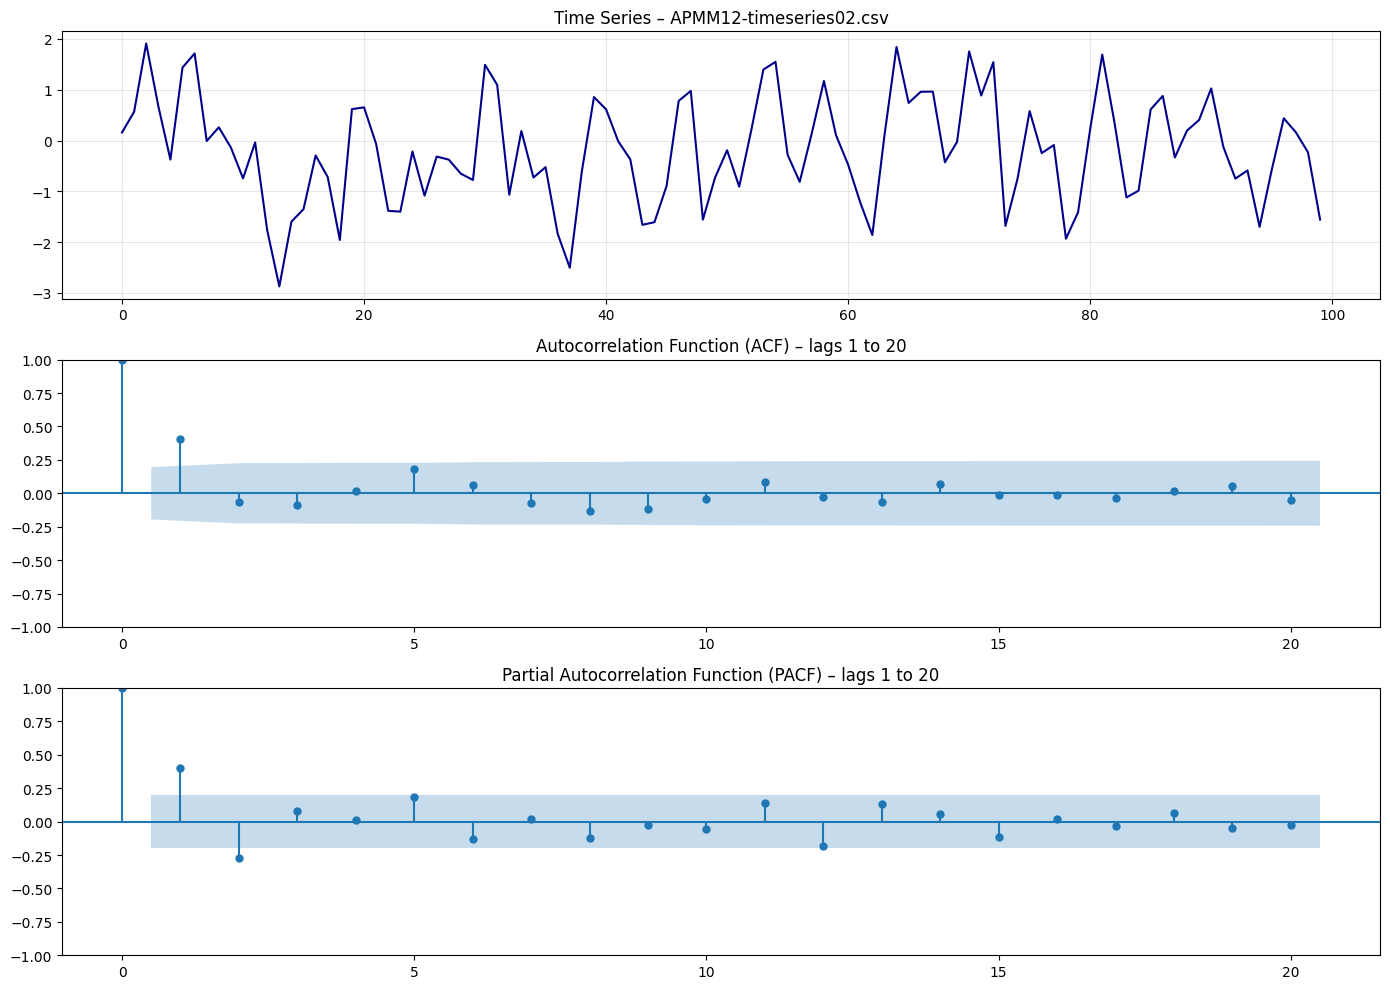

FINAL ANSWER
Significant ACF  bars (outside 95% CI): 1
Significant PACF bars (outside 95% CI): 3


In [15]:
# --------------------------- 2. Compute ACF ----------------------------------
acf_vals, acf_confint = acf(ts, nlags=20, alpha=0.05, fft=False)
# acf_vals[0] = 1.0 (lag-0), acf_vals[1:] are lags 1–20

# --------------------------- 3. Compute PACF ---------------------------------
pacf_vals, pacf_confint = pacf(ts, nlags=20, alpha=0.05)
# pacf_vals[0] is always NaN or undefined, pacf_vals[1:] are lags 1–20

# --------------------------- 4. Count significant bars -----------------------
ci = 1.96 / (len(ts)**0.5)   # ≈ 0.196 for n=100

# ACF
significant_acf = sum(abs(acf_vals[1:]) > ci)
# PACF (skip index 0 which is NaN)
significant_pacf = sum(abs(pacf_vals[1:]) > ci)

print("=== AUTOCORRELATION FUNCTION (ACF) ===")
print(f"{'Lag':>3} {'ACF':>10} {'Significant?':>12}")
for lag in range(1, 21):
    val = acf_vals[lag]
    sig = "YES" if abs(val) > ci else "no"
    print(f"{lag:3d} {val:10.4f}        {sig}")

print(f"\nNumber of significant ACF bars (lags 1–20): {significant_acf}\n")

print("=== PARTIAL AUTOCORRELATION FUNCTION (PACF) ===")
print(f"{'Lag':>3} {'PACF':>10} {'Significant?':>12}")
for lag in range(1, 21):
    val = pacf_vals[lag]
    sig = "YES" if abs(val) > ci else "no"
    print(f"{lag:3d} {val:10.4f}        {sig}")

print(f"\nNumber of significant PACF bars (lags 1–20): {significant_pacf}\n")

# --------------------------- 5. Plot everything -------------------------------
plt.figure(figsize=(14, 10))

# Time series
plt.subplot(3, 1, 1)
plt.plot(ts, color='darkblue')
plt.title('Time Series – APMM12-timeseries02.csv')
plt.grid(alpha=0.3)

# ACF plot
plt.subplot(3, 1, 2)
plot_acf(ts, lags=20, ax=plt.gca(), title='Autocorrelation Function (ACF) – lags 1 to 20')

# PACF plot
plt.subplot(3, 1, 3)
plot_pacf(ts, lags=20, ax=plt.gca(), title='Partial Autocorrelation Function (PACF) – lags 1 to 20')

plt.tight_layout()
plt.show()

# Final answer
print("FINAL ANSWER")
print("="*50)
print(f"Significant ACF  bars (outside 95% CI): {significant_acf}")
print(f"Significant PACF bars (outside 95% CI): {significant_pacf}")

In [16]:
df1 = pd.read_csv('/Users/maheshg/Dropbox/Sample Datasets Kaggle/APMM12-timeseries04.csv')

In [19]:
ts = df1['value']

In [20]:
ts.head()

0   -0.408873
1   -0.995491
2   -2.774890
3   -5.787595
4   -7.870965
Name: value, dtype: float64

Partial Autocorrelation Function (PACF) – Lags 1 to 20
Lag    PACF       |PACF|     Significant?
---------------------------------------------
 1     0.986701     0.987          YES
 2    -0.161993     0.162          YES
 3    -0.090993     0.091          no
 4    -0.048599     0.049          no
 5    -0.056572     0.057          no
 6    -0.067555     0.068          no
 7    -0.105985     0.106          no
 8    -0.064330     0.064          no
 9    -0.031956     0.032          no
10    -0.027061     0.027          no
11    -0.014928     0.015          no
12    -0.003910     0.004          no
13     0.044646     0.045          no
14     0.016387     0.016          no
15     0.002328     0.002          no
16     0.002800     0.003          no
17     0.038962     0.039          no
18     0.038980     0.039          no
19     0.011926     0.012          no
20    -0.039938     0.040          no

95% confidence interval width ≈ ±0.139
Number of significant PACF bars (lags 1–20): 2


<Figure size 1000x500 with 0 Axes>

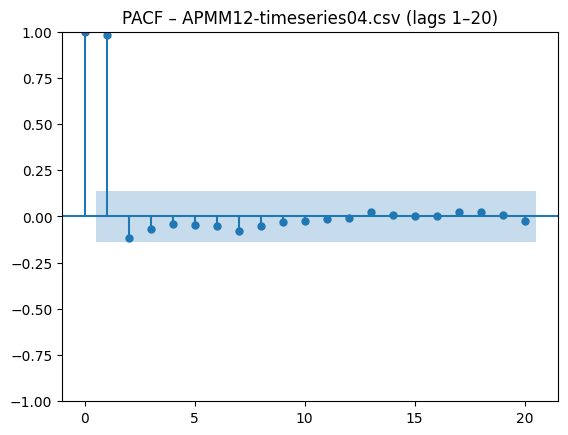

In [21]:
# 2. Compute PACF up to lag 20
pacf_vals, confint = pacf(ts, nlags=20, alpha=0.05)

# confint shape: (21×2 → we only need lags 1–20
lower = confint[1:, 0] - pacf_vals[1:]   # distance from PACF to lower bound
upper = confint[1:, 1] - pacf_vals[1:]   # distance from PACF to upper bound
ci_width = 1.96 / np.sqrt(len(ts))       # ≈ 0.145 for n=182

# 3. Count how many are significant (outside the confidence band)
significant = np.abs(pacf_vals[1:]) > ci_width
num_significant = np.sum(significant).sum()

# 4. Print nice table
print("Partial Autocorrelation Function (PACF) – Lags 1 to 20")
print("Lag    PACF       |PACF|     Significant?")
print("-" * 45)
for lag in range(1, 21):
    print(f"{lag:2d}    {pacf_vals[lag]: .6f}     {abs(pacf_vals[lag]):.3f}          {'YES' if abs(pacf_vals[lag]) > ci_width else 'no'}")

print("\n" + "="*50)
print(f"95% confidence interval width ≈ ±{ci_width:.3f}")
print(f"Number of significant PACF bars (lags 1–20): {num_significant}")
print("="*50)

# 5. Plot (optional – very useful to see it visually)
plt.figure(figsize=(10, 5))
plot_pacf(ts, lags=20, method='ywm')
plt.title('PACF – APMM12-timeseries04.csv (lags 1–20)')
plt.show()

In [22]:
df2 = pd.read_csv('/Users/maheshg/Dropbox/Sample Datasets Kaggle/APMM12-timeseries02.csv')

In [23]:
ts = df2['value']

In [25]:
from statsmodels.tsa.arima.model import ARIMA

In [26]:
model = ARIMA(ts,order =(1,0,0))
results = model.fit()
print(results.summary())

                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                  100
Model:                 ARIMA(1, 0, 0)   Log Likelihood                -132.206
Date:                Thu, 27 Nov 2025   AIC                            270.413
Time:                        07:17:10   BIC                            278.228
Sample:                             0   HQIC                           273.576
                                - 100                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.4658      0.407     -1.146      0.252      -1.263       0.331
ar.L1          0.7787      0.058     13.516      0.000       0.666       0.892
sigma2         0.8162      0.125      6.522      0.0

In [27]:
df2 = pd.read_csv('/Users/maheshg/Dropbox/Sample Datasets Kaggle/APMM12-timeseries02.csv')

In [28]:
ts = df2['value']

Lag   ACF value     |ACF|     Outside 95% CI?
---------------------------------------------
 1    +0.782564     0.783        YES
 2    +0.614773     0.615        YES
 3    +0.495452     0.495        YES
 4    +0.407717     0.408        YES
 5    +0.366610     0.367        YES
 6    +0.251790     0.252        YES
 7    +0.156684     0.157        no
 8    +0.067842     0.068        no
 9    +0.044086     0.044        no
10    +0.019697     0.020        no
11    +0.042491     0.042        no
12    -0.001544     0.002        no
13    -0.027087     0.027        no
14    +0.005427     0.005        no
15    -0.040494     0.040        no
16    -0.028103     0.028        no
17    -0.038206     0.038        no
18    -0.020692     0.021        no
19    -0.020360     0.020        no
20    -0.048823     0.049        no

95% confidence band approximately ±0.196
Number of important bars (significant at 5%): 6


<Figure size 1000x400 with 0 Axes>

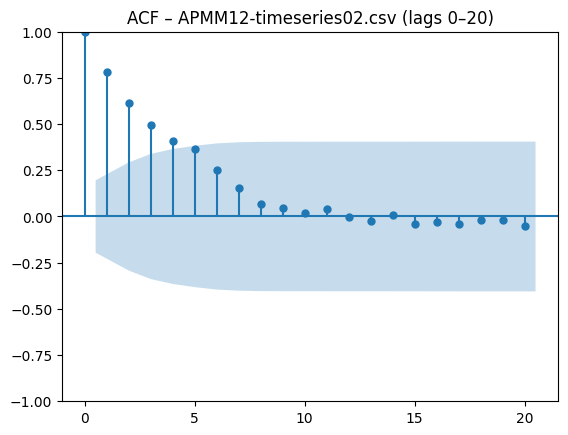

In [29]:
# 2. Compute ACF up to lag 20
acf_values, confint = acf(ts, nlags=20, alpha=0.05, fft=False)

# 3. The confidence interval width (same for all lags in large samples)
ci = 1.96 / np.sqrt(len(ts))        # approximately 0.196 for n=100

# 4. Count how many lags (1 to 20) are significant
significant_count = sum(abs(acf_values[1:]) > ci)   # we skip lag 0 (always 1)

# 5. Print detailed table
print("Lag   ACF value     |ACF|     Outside 95% CI?")
print("---------------------------------------------")
for lag in range(1, 21):
    val = acf_values[lag]
    outside = "YES" if abs(val) > ci else "no"
    print(f"{lag:2d}    {val:+.6f}     {abs(val):.3f}        {outside}")

print("\n" + "="*50)
print(f"95% confidence band approximately ±{ci:.3f}")
print(f"Number of important bars (significant at 5%): {significant_count}")
print("="*50)

# 6. Plot the ACF (looks exactly like in your course)
plt.figure(figsize=(10, 4))
plot_acf(ts, lags=20, alpha=0.05, title="ACF – APMM12-timeseries02.csv (lags 0–20)")
plt.show()

Lag    PACF value      |PACF|     Outside 95% CI?
---------------------------------------------------
 1     +0.782564      0.783          YES
 2     +0.006108      0.006          no
 3     +0.032282      0.032          no
 4     +0.022931      0.023          no
 5     +0.083325      0.083          no
 6     -0.186542      0.187          no
 7     -0.031172      0.031          no
 8     -0.071885      0.072          no
 9     +0.091562      0.092          no
10     -0.048786      0.049          no
11     +0.153270      0.153          no
12     -0.163175      0.163          no
13     +0.060733      0.061          no
14     +0.056298      0.056          no
15     -0.151958      0.152          no
16     +0.045306      0.045          no
17     +0.009297      0.009          no
18     +0.055651      0.056          no
19     -0.065687      0.066          no
20     -0.031240      0.031          no

95% confidence interval ≈ ±0.196
Number of important/significant bars (lags 1–20): 1


<Figure size 1000x450 with 0 Axes>

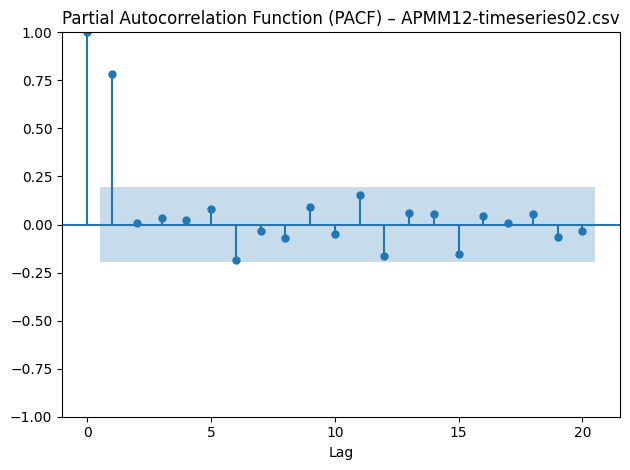

In [30]:
# 2. Compute PACF up to lag 20
pacf_values, confint = pacf(ts, nlags=20, alpha=0.05, method='ywmle')  # standard method

# 3. Approximate 95% confidence interval width (same for all lags when n is large)
ci_width = 1.96 / np.sqrt(len(ts))          # ≈ 0.196 for n=100

# 4. Count how many PACF bars (lags 1–20) are significant
significant_count = sum(abs(pacf_values[1:]) > ci_width)

# 5. Print a clear table
print("Lag    PACF value      |PACF|     Outside 95% CI?")
print("---------------------------------------------------")
for lag in range(1, 21):
    val = pacf_values[lag]
    outside = "YES" if abs(val) > ci_width else "no"
    print(f"{lag:2d}     {val:+.6f}      {abs(val):.3f}          {outside}")

print("\n" + "="*55)
print(f"95% confidence interval ≈ ±{ci_width:.3f}")
print(f"Number of important/significant bars (lags 1–20): {significant_count}")
print("="*55)

# 6. Plot the PACF exactly like in textbooks / online courses
plt.figure(figsize=(10, 4.5))
plot_pacf(ts, lags=20, alpha=0.05, method='ywmle',
          title='Partial Autocorrelation Function (PACF) – APMM12-timeseries02.csv')
plt.xlabel('Lag')
plt.tight_layout()
plt.show()

Lag    PACF value      |PACF|     Outside 95% CI?
---------------------------------------------------
 1     +0.782564      0.783          YES
 2     +0.006108      0.006          no
 3     +0.032282      0.032          no
 4     +0.022931      0.023          no
 5     +0.083325      0.083          no
 6     -0.186542      0.187          no
 7     -0.031172      0.031          no
 8     -0.071885      0.072          no
 9     +0.091562      0.092          no
10     -0.048786      0.049          no
11     +0.153270      0.153          no
12     -0.163175      0.163          no
13     +0.060733      0.061          no
14     +0.056298      0.056          no
15     -0.151958      0.152          no
16     +0.045306      0.045          no
17     +0.009297      0.009          no
18     +0.055651      0.056          no
19     -0.065687      0.066          no
20     -0.031240      0.031          no

95% confidence interval ≈ ±0.196
Number of important/significant bars (lags 1–20): 1


<Figure size 1000x450 with 0 Axes>

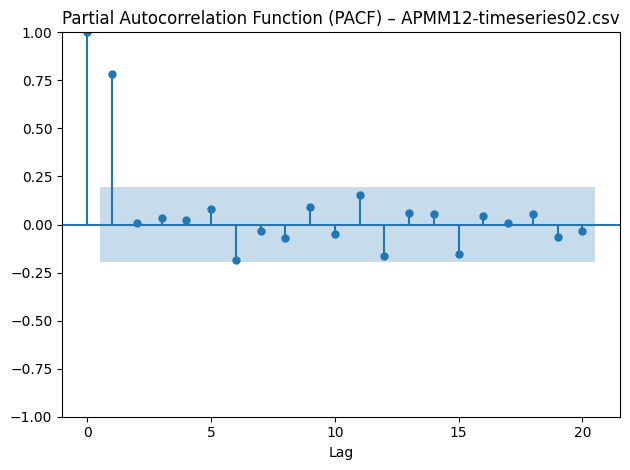

In [33]:
# 2. Compute PACF up to lag 20
pacf_values, confint = pacf(ts, nlags=20, alpha=0.05, method='ywmle')  # standard method

# 3. Approximate 95% confidence interval width (same for all lags when n is large)
ci_width = 1.96 / np.sqrt(len(ts))          # ≈ 0.196 for n=100

# 4. Count how many PACF bars (lags 1–20) are significant
significant_count = sum(abs(pacf_values[1:]) > ci_width)

# 5. Print a clear table
print("Lag    PACF value      |PACF|     Outside 95% CI?")
print("---------------------------------------------------")
for lag in range(1, 21):
    val = pacf_values[lag]
    outside = "YES" if abs(val) > ci_width else "no"
    print(f"{lag:2d}     {val:+.6f}      {abs(val):.3f}          {outside}")

print("\n" + "="*55)
print(f"95% confidence interval ≈ ±{ci_width:.3f}")
print(f"Number of important/significant bars (lags 1–20): {significant_count}")
print("="*55)

# 6. Plot the PACF exactly like in textbooks / online courses
plt.figure(figsize=(10, 4.5))
plot_pacf(ts, lags=20, alpha=0.05, method='ywmle',
          title='Partial Autocorrelation Function (PACF) – APMM12-timeseries02.csv')
plt.xlabel('Lag')
plt.tight_layout()
plt.show()

In [34]:
from sklearn.ensemble import RandomForestRegressor

In [42]:
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

In [43]:
log_cfl = LogisticRegression()
svm_cfl = SVC() 
rnd_clf = RandomForestRegressor()

In [44]:

log_clf = LogisticRegression()
rnd_clf = RandomForestClassifier()
svm_clf = SVC()

voting_clf = VotingClassifier(
    estimators=[('lr', log_clf), ('rf', rnd_clf), ('svc', svm_clf)],
    voting='hard')
voting_clf.fit(X_train, y_train)


NameError: name 'X_train' is not defined